<a href="https://colab.research.google.com/github/DimiGretsistas/lab-control-flow-en/blob/master/Model_11(84_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
#
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

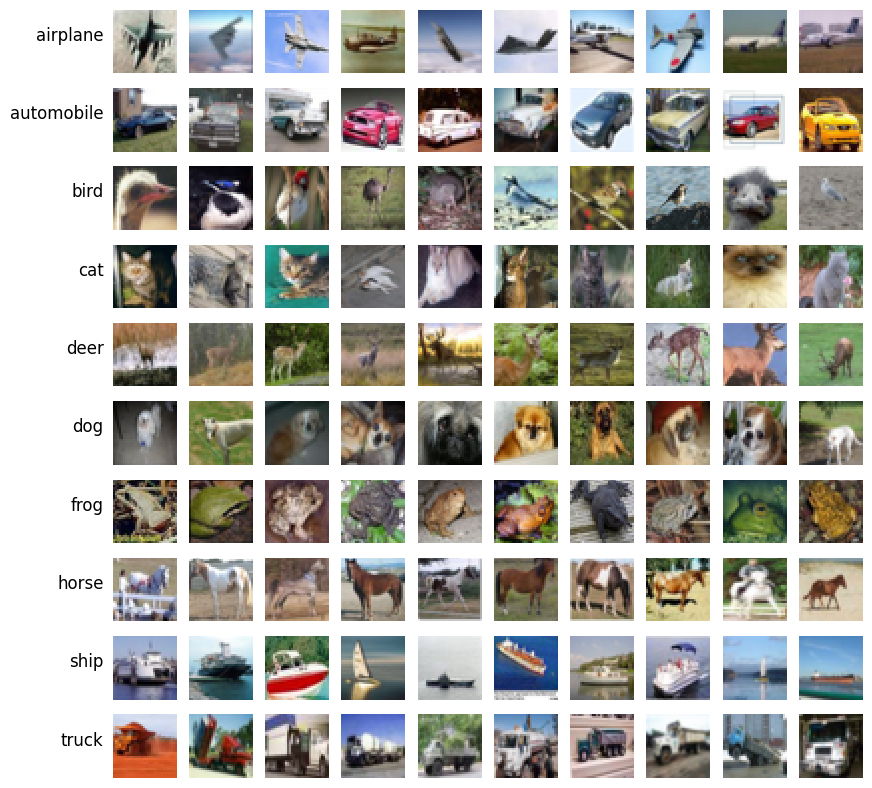

In [ ]:
# Class names
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# Create 10x10 grid
plt.figure(figsize=(10,10))

for class_idx in range(10):
  # Get indices of this class (finds images of a specific class)
  idx = np.where(y_train.flatten() == class_idx)[0]

  # Pick 10 random samples
  random_idx = np.random.choice(idx, 10, replace=False)

  for i, idx in enumerate(random_idx):
    plt_idx = class_idx * 10 + i + 1
    plt.subplot(10, 10, plt_idx)
    plt.imshow(x_train[idx])
    plt.axis('off')


    # Show class name clearly on the left
    if i == 0:
      plt.text(-5, 15, classes[class_idx], fontsize=12, ha='right')

plt.subplots_adjust(left=0.15)  # creates space so labels aren’t cut off
plt.show()

# Convert the labels to one-hot encoded form.
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Normalize the images
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

In [ ]:
from keras.backend import clear_session
clear_session()

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras import optimizers

base_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

base_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
# opt = optimizers.Adam(learning_rate=0.01)

base_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = base_model.fit(
    x_train_normalized,
    y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3537 - loss: 1.8223 - val_accuracy: 0.4500 - val_loss: 1.5925
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4895 - loss: 1.4664 - val_accuracy: 0.5194 - val_loss: 1.3890
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5419 - loss: 1.3136 - val_accuracy: 0.5437 - val_loss: 1.3114
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5712 - loss: 1.2290 - val_accuracy: 0.5615 - val_loss: 1.2800
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5944 - loss: 1.1636 - val_accuracy: 0.5784 - val_loss: 1.2162
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6133 - loss: 1.1122 - val_accuracy: 0.5709 - val_loss: 1.2247
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6222 - loss: 1.0823 - val_accuracy: 0.5880 - val_loss: 1.1792
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6364 - loss: 1.0477 - val_accuracy: 0.5991 - v

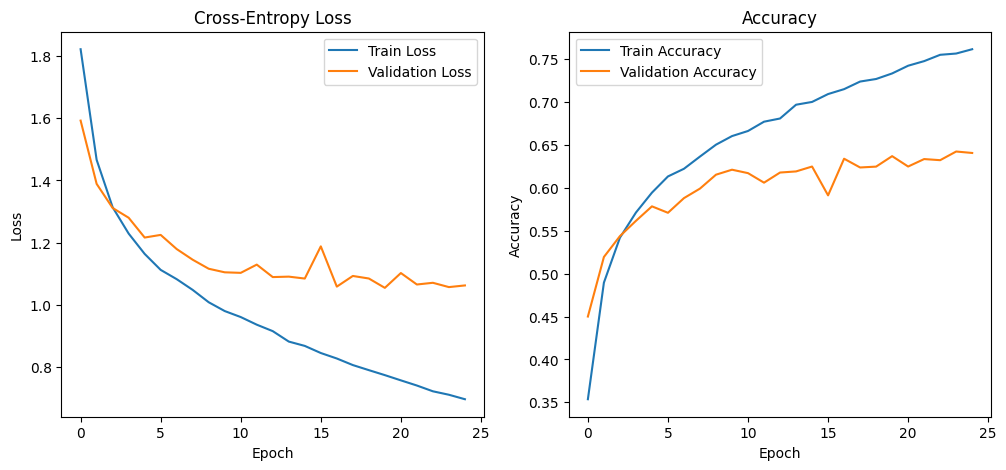

In [ ]:
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = base_model.evaluate(x_test_normalized, y_test)

print("Test Accuracy for base model:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6379 - loss: 1.0555
Test Accuracy for base model: 0.6378999948501587


In [ ]:
# Save model
base_model.save("base_model.keras")

In [ ]:
from keras.backend import clear_session
clear_session()

In [ ]:
import keras
load_model = keras.saving.load_model("base_model.keras")
load_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,166,020 (8.26 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,444,014 (5.51 MB)

In [ ]:
from tensorflow.keras.layers import Dropout, BatchNormalization, RandomFlip, RandomRotation, RandomZoom, GlobalAveragePooling2D, Input

# Create data augmentation
data_augmentation = keras.Sequential([
  RandomFlip("horizontal"),
  RandomRotation(0.1),
  RandomZoom(0.1),
])

#Create Layers
model_11 = keras.Sequential([
    Input(shape=(32, 32, 3)),

    data_augmentation,

    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])


model_11.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,114 (1.17 MB)

 Trainable params: 305,962 (1.17 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
#Compile Model
model_11.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

#Train model
# Train the model
history_11 = model_11.fit(
    x_train_normalized,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.4563 - loss: 1.5038 - val_accuracy: 0.4901 - val_loss: 1.4495
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5928 - loss: 1.1445 - val_accuracy: 0.6046 - val_loss: 1.1737
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6555 - loss: 0.9783 - val_accuracy: 0.6711 - val_loss: 0.9726
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6964 - loss: 0.8724 - val_accuracy: 0.6353 - val_loss: 1.0795
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7197 - loss: 0.8009 - val_accuracy: 0.7097 - val_loss: 0.8804
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7429 - loss: 0.7396 - val_accuracy: 0.7179 - val_loss: 0.8432
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7559 - loss: 0.6991 - val_accuracy: 0.7391 - val_loss: 0.7845
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7693 - loss: 0.6664 - 

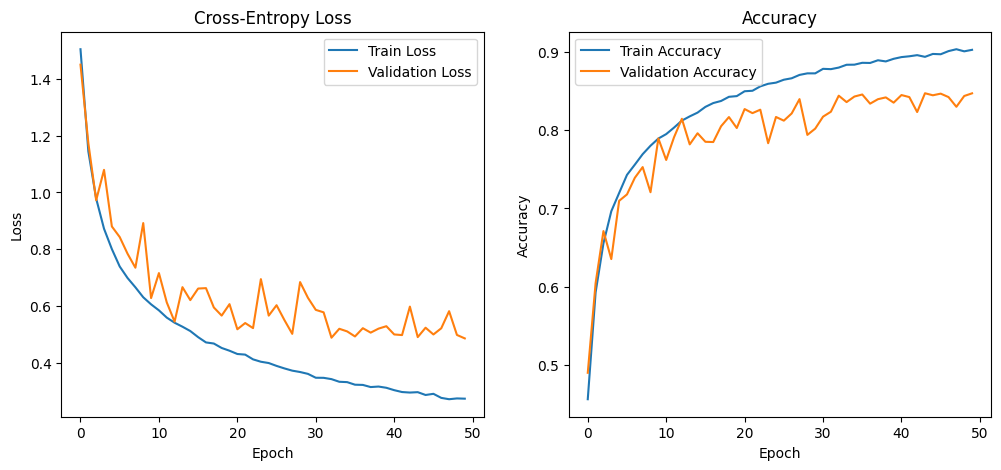

In [ ]:
#Create the plots
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history_11.history['loss'], label='Train Loss')
plt.plot(history_11.history['val_loss'], label='Validation Loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_11.history['accuracy'], label='Train Accuracy')
plt.plot(history_11.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
#Evaluate Test Accuracy
test_loss, test_accuracy = model_11.evaluate(x_test_normalized, y_test)

print("Test Accuracy for model 11:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8406 - loss: 0.5145
Test Accuracy for model 11: 0.8406000137329102


In [ ]:
model_11.save("model_11.keras")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


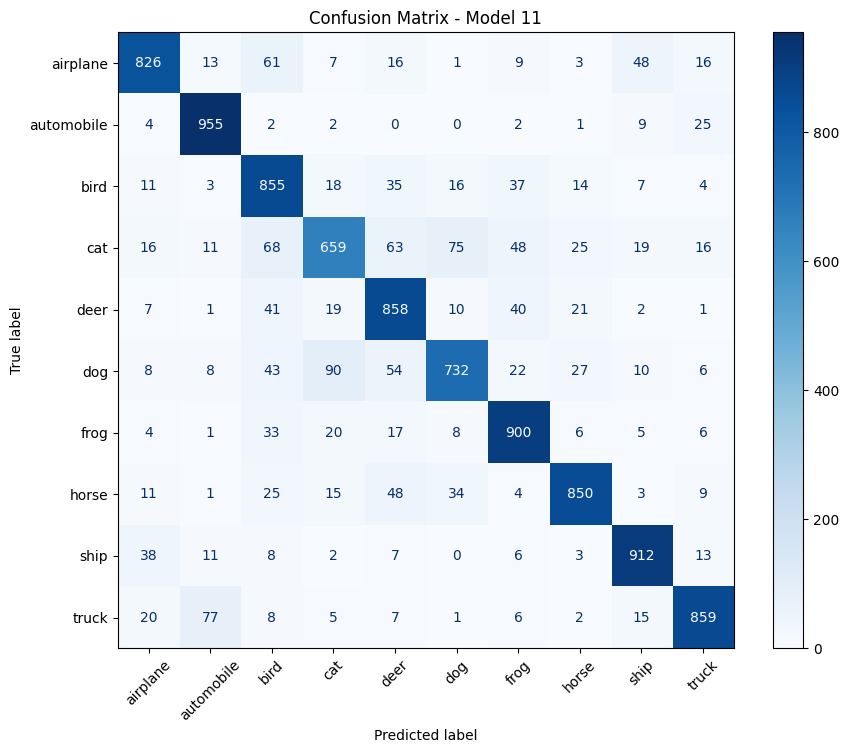

airplane is most confused with bird (61 times)
automobile is most confused with truck (25 times)
bird is most confused with frog (37 times)
cat is most confused with dog (75 times)
deer is most confused with bird (41 times)
dog is most confused with cat (90 times)
frog is most confused with bird (33 times)
horse is most confused with deer (48 times)
ship is most confused with airplane (38 times)
truck is most confused with automobile (77 times)


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = model_11.predict(x_test_normalized)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix with class names
fig, ax = plt.subplots(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix - Model 11")
plt.xticks(rotation=45)
plt.show()

for i in range(len(classes)):
    row = cm[i].copy()
    row[i] = 0
    most_confused_with = np.argmax(row)

    print(f"{classes[i]} is most confused with {classes[most_confused_with]} ({row[most_confused_with]} times)")